In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from scipy import stats

In [3]:
# Cargar la base de datos
data = load_iris()
data

{'data': array([[5.1, 3.5, 1.4, 0.2],
        [4.9, 3. , 1.4, 0.2],
        [4.7, 3.2, 1.3, 0.2],
        [4.6, 3.1, 1.5, 0.2],
        [5. , 3.6, 1.4, 0.2],
        [5.4, 3.9, 1.7, 0.4],
        [4.6, 3.4, 1.4, 0.3],
        [5. , 3.4, 1.5, 0.2],
        [4.4, 2.9, 1.4, 0.2],
        [4.9, 3.1, 1.5, 0.1],
        [5.4, 3.7, 1.5, 0.2],
        [4.8, 3.4, 1.6, 0.2],
        [4.8, 3. , 1.4, 0.1],
        [4.3, 3. , 1.1, 0.1],
        [5.8, 4. , 1.2, 0.2],
        [5.7, 4.4, 1.5, 0.4],
        [5.4, 3.9, 1.3, 0.4],
        [5.1, 3.5, 1.4, 0.3],
        [5.7, 3.8, 1.7, 0.3],
        [5.1, 3.8, 1.5, 0.3],
        [5.4, 3.4, 1.7, 0.2],
        [5.1, 3.7, 1.5, 0.4],
        [4.6, 3.6, 1. , 0.2],
        [5.1, 3.3, 1.7, 0.5],
        [4.8, 3.4, 1.9, 0.2],
        [5. , 3. , 1.6, 0.2],
        [5. , 3.4, 1.6, 0.4],
        [5.2, 3.5, 1.5, 0.2],
        [5.2, 3.4, 1.4, 0.2],
        [4.7, 3.2, 1.6, 0.2],
        [4.8, 3.1, 1.6, 0.2],
        [5.4, 3.4, 1.5, 0.4],
        [5.2, 4.1, 1.5, 0.1],
  

In [4]:
df =pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [5]:
df.describe()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


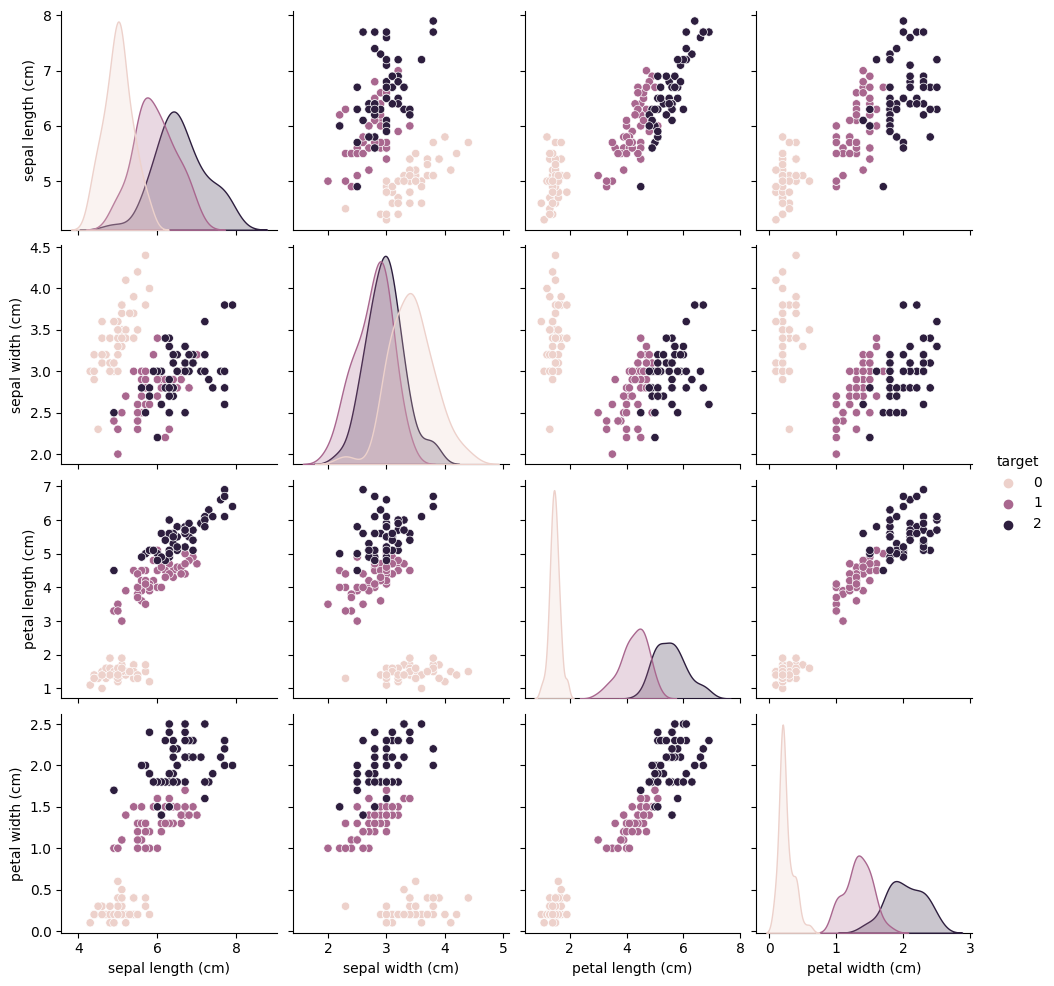

In [6]:
sns.pairplot(df, hue='target')

<Axes: >

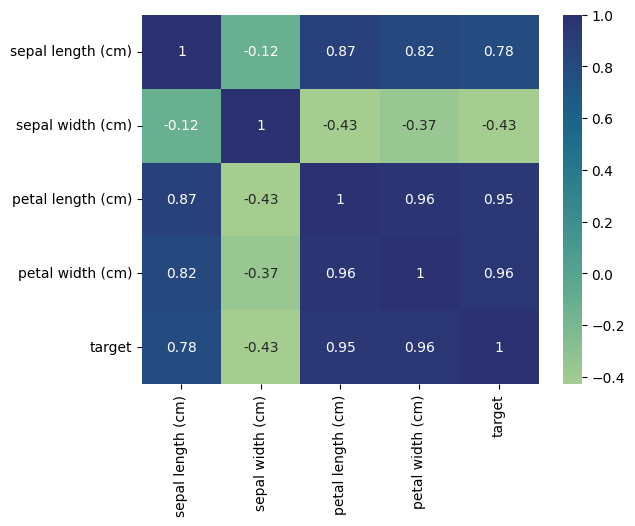

In [7]:
sns.heatmap(df.corr(),  annot=True, cmap="crest")

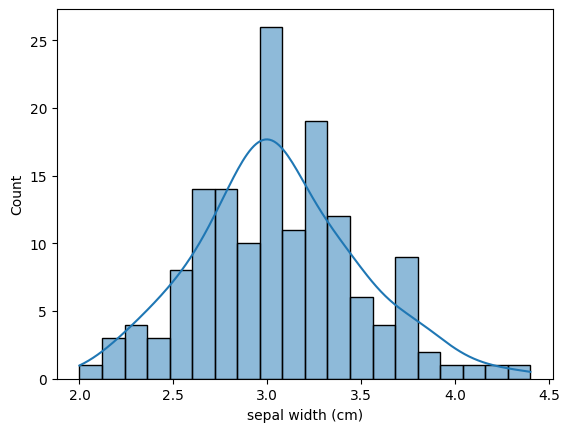

In [8]:
# Histograma
sns.histplot(df['sepal width (cm)'], kde=True, bins=20)
plt.show()

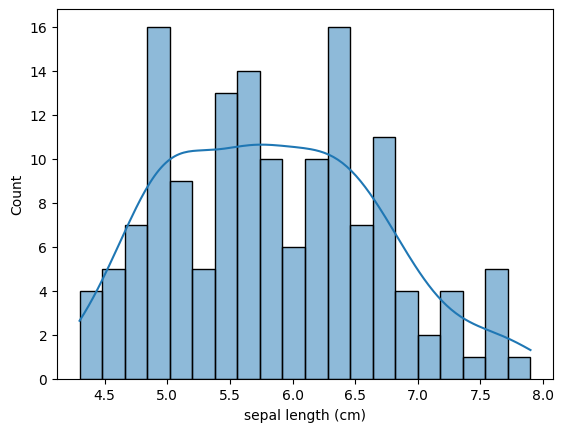

In [10]:
# Histograma
sns.histplot(df['sepal length (cm)'], kde=True, bins=20)
plt.show()

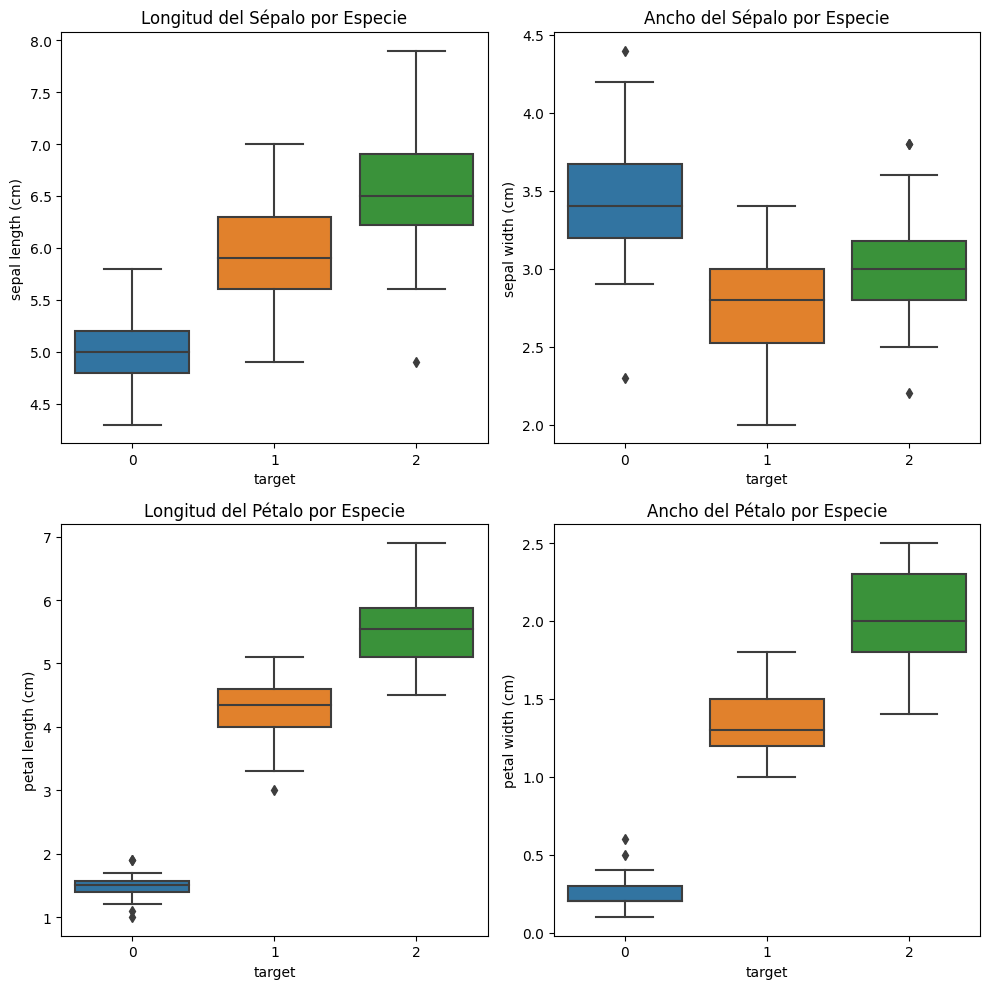

In [11]:
# Crear boxplots para cada tipo de flor y sus medidas
plt.figure(figsize=(10, 10))

# Boxplot para la longitud del sépalo
plt.subplot(2, 2, 1)
sns.boxplot(x='target', y='sepal length (cm)', data=df)
plt.title('Longitud del Sépalo por Especie')

# Boxplot para el ancho del sépalo
plt.subplot(2, 2, 2)
sns.boxplot(x='target', y='sepal width (cm)', data=df)
plt.title('Ancho del Sépalo por Especie')

# Boxplot para la longitud del pétalo
plt.subplot(2, 2, 3)
sns.boxplot(x='target', y='petal length (cm)', data=df)
plt.title('Longitud del Pétalo por Especie')

# Boxplot para el ancho del pétalo
plt.subplot(2, 2, 4)
sns.boxplot(x='target', y='petal width (cm)', data=df)
plt.title('Ancho del Pétalo por Especie')

plt.tight_layout()
plt.show()

Esta es una prueba para la hipótesis nula de que el valor esperado (media) de una muestra de observaciones independientes a es igual a la media poblacional dada, popmean.

In [12]:
# Prueba T para una muestra

t_stat, p_value = stats.ttest_1samp(df['sepal length (cm)'], popmean=5.0, alternative= 'greater')
print('T-statistic:', t_stat)
print('P-value:', p_value)

T-statistic: 12.473257146694761
P-value: 3.3353711499009633e-25


In [15]:
t_stat, p_value = stats.ttest_1samp(df['sepal length (cm)'], popmean=5.0, alternative= 'less')
print('T-statistic:', t_stat)
print('P-value:', p_value)

T-statistic: 12.473257146694761
P-value: 1.0


In [13]:
t_stat, p_value = stats.ttest_1samp(df['sepal length (cm)'], popmean=5.0, alternative= 'two-sided')
print('T-statistic:', t_stat)
print('P-value:', p_value)

T-statistic: 12.473257146694761
P-value: 6.670742299801927e-25


Esta es una prueba para la hipótesis nula de que dos muestras independientes tienen valores promedio (esperados) idénticos.

In [21]:
# Extraer los datos de las especies setosa y versicolor
setosa = df[df['target'] == 0]['sepal length (cm)']
versicolor = df[df['target'] == 1]['sepal length (cm)']

# Realizar la prueba T
t_stat, p_value = stats.ttest_ind(setosa, versicolor)

print("Estadístico T:", t_stat)
print("P-valor:", p_value)


Estadístico T: -10.52098626754911
P-valor: 8.985235037487079e-18


In [22]:
# Extraer los datos de las especies setosa y versicolor
setosa = df[df['target'] == 0]['sepal length (cm)']
versicolor = df[df['target'] == 1]['sepal length (cm)']

# Realizar la prueba T
t_stat, p_value = stats.ttest_ind(setosa, versicolor, alternative='less')

print("Estadístico T:", t_stat)
print("P-valor:", p_value)


Estadístico T: -10.52098626754911
P-valor: 4.4926175187435395e-18


In [23]:
# Extraer los datos de las especies setosa y versicolor
setosa = df[df['target'] == 0]['sepal length (cm)']
versicolor = df[df['target'] == 1]['sepal length (cm)']

# Realizar la prueba T
t_stat, p_value = stats.ttest_ind(setosa, versicolor, alternative='greater')

print("Estadístico T:", t_stat)
print("P-valor:", p_value)

Estadístico T: -10.52098626754911
P-valor: 1.0


In [24]:
# Extraer los datos de las especies setosa y versicolor
setosa = df[df['target'] == 0]['sepal length (cm)']
versicolor = df[df['target'] == 1]['sepal length (cm)']

# Realizar la prueba T
t_stat, p_value = stats.ttest_ind(setosa, versicolor, equal_var= False)

print("Estadístico T:", t_stat)
print("P-valor:", p_value)

Estadístico T: -10.52098626754911
P-valor: 3.746742613983842e-17


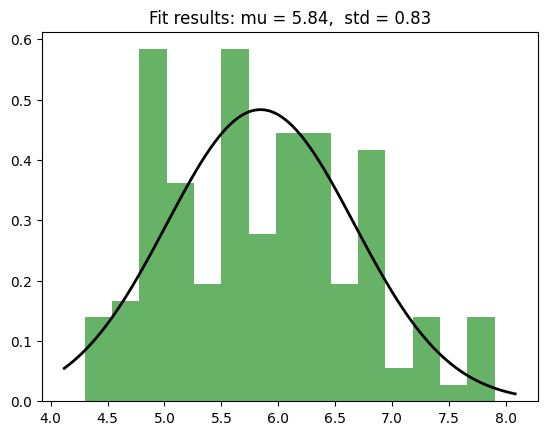

In [25]:
# Ajustar una distribución normal
mu, std = stats.norm.fit(df['sepal length (cm)'])

# Plotear la PDF de la distribución normal ajustada
plt.hist(df['sepal length (cm)'], bins=15, density=True, alpha=0.6, color="g")
xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)
p = stats.norm.pdf(x, mu, std)
plt.plot(x, p, 'k', linewidth=2)
title = "Fit results: mu = %.2f,  std = %.2f" % (mu, std)
plt.title(title)
plt.show()

1. **¿Cuál es la probabilidad de que una flor Iris tenga una longitud de sépalo menor a 5 cm?**
   
   Puedes calcular esto usando la función de distribución acumulativa (CDF) de la distribución normal ajustada.


In [29]:
   prob = stats.norm.cdf(5, mu, std)
   print("Probabilidad de que la longitud de sépalo sea menor a 5 cm:", prob)

Probabilidad de que la longitud de sépalo sea menor a 5 cm: 0.15342617720079227



2. **¿Y si quisiéramos saber la probabilidad de que una flor Iris tenga una longitud de sépalo entre 5 cm y 6 cm?**

   Puedes calcular la diferencia entre las CDFs en los dos puntos.
   


In [28]:
   prob = stats.norm.cdf(6, mu, std) - stats.norm.cdf(5, mu, std)
   print("Probabilidad de que la longitud de sépalo esté entre 5 cm y 6 cm:", prob)

Probabilidad de que la longitud de sépalo esté entre 5 cm y 6 cm: 0.42185251767296345


3. **Si seleccionamos una flor Iris al azar, ¿cuál es la longitud de sépalo que separa al 25% más bajo de las flores del resto?**
   
   Esto se llama el cuantil o percentil 25, y puedes calcularlo usando la función `ppf` (Percent-Point Function), que es la inversa de la CDF.
   


In [27]:
   q25 = stats.norm.ppf(0.25, mu, std)
   print("El 25% de las flores tienen una longitud de sépalo menor a:", q25, "cm")

El 25% de las flores tienen una longitud de sépalo menor a: 5.28667607120067 cm


4. **¿Cómo es la simetría de la distribución de longitudes de sépalos? ¿Podemos usar la distribución normal ajustada para verificar esto?**

   Sí, puedes mirar la desviación estándar y la media. En una distribución normal, aproximadamente el 68% de los datos debería estar dentro de una desviación estándar de la media. Puedes verificar si esto es cierto para tu conjunto de datos.


In [26]:
   within_one_std = sum((df['sepal length (cm)'] > mu - std) & (df['sepal length (cm)'] < mu + std)) / len(df)
   print("Porcentaje de datos dentro de una desviación estándar de la media:", within_one_std * 100)

Porcentaje de datos dentro de una desviación estándar de la media: 60.0


In [16]:
pip install fitter

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.6/11.6 MB 57.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.3/12.3 MB 80.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 341.8/341.8 kB 34.1 MB/s eta 0:00:00
  Created wheel for fitter: filename=fitter-1.6.0-py3-none-any.whl size=26058 sha256=8de68274dc1c5519b17e7e8c22505ad7725a91a403220771097f374f364a286c
  Stored in directory: /root/.cache/pip/wheels/26/f9/51/059fcaf0ba5aafd94463e31b343453c5cf165cea425f25c0f9
Successfully built fitter
  Attempting uninstall: pandas
    Found existing installation: pandas 1.5.3
    Uninstalling pandas-1.5.3:
      Successfully uninstalled pandas-1.5.3
  Attempting uninstall: matplotlib
    Found existing installation: matplotlib 3.7.1
    Uninstalling matplotlib-3.7.1:
      Successfully uninstalled matplotlib-3.7.1
ERROR: pip's depe

,sumsquare_error,aic,bic,kl_div,ks_statistic,ks_pvalue
gamma,21.807264,314.587931,323.619836,inf,0.081909,2.525253e-01
lognorm,21.827199,316.139102,325.171008,inf,0.086502,1.997368e-01
norm,21.840426,317.604296,323.625567,inf,0.089454,1.705836e-01
t,21.840491,319.616008,328.647914,inf,0.089456,1.705713e-01
expon,24.660651,324.050255,330.071526,inf,0.217973,9.751278e-07


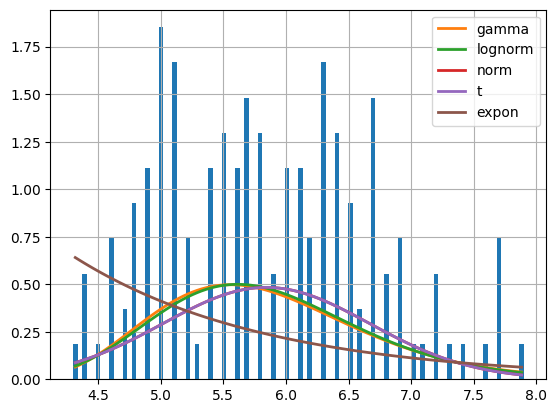

In [17]:
from fitter import Fitter

data = df['sepal length (cm)']

f = Fitter(data, distributions=['norm', 'expon', 'lognorm', 't', 'gamma'])
f.fit()
f.summary()


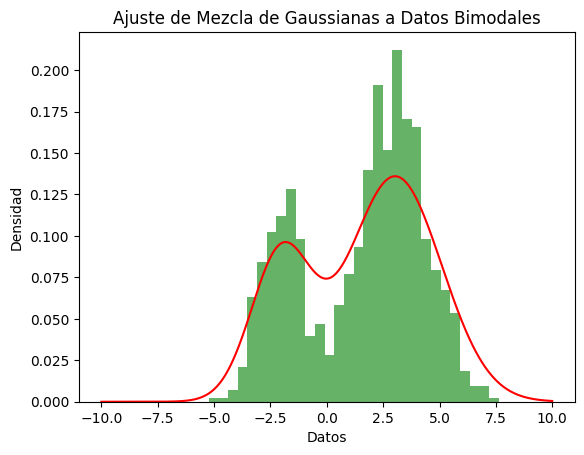

In [18]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.mixture import GaussianMixture
from sklearn.datasets import make_spd_matrix

# Crear algunos datos bimodales
np.random.seed(42)
data1 = np.random.normal(loc=-2, scale=1, size=300)
data2 = np.random.normal(loc=3, scale=1.5, size=700)
data = np.concatenate([data1, data2]).reshape(-1, 1)

# Visualizar los datos
plt.hist(data, bins=30, density=True, alpha=0.6, color='g')

# Ajustar un modelo de mezcla de Gaussianas
gmm = GaussianMixture(n_components=2, random_state=42)
gmm.fit(data)

# Obtener los parámetros ajustados
means = gmm.means_.flatten()
weights = gmm.weights_.flatten()
covariances = [make_spd_matrix(1, random_state=42)*var[0][0] for var in gmm.covariances_]

# Crear un rango de valores para visualizar la distribución ajustada
x = np.linspace(-10, 10, 1000)
pdf = np.zeros_like(x)

# Calcular la función de densidad de probabilidad de la mezcla de Gaussianas
for mean, weight, covariance in zip(means, weights, covariances):
    pdf += weight * (1/np.sqrt(2*np.pi*covariance[0])) * np.exp(-0.5 * ((x - mean) ** 2) / covariance[0])

# Visualizar el resultado
plt.plot(x, pdf, color="red")
plt.title('Ajuste de Mezcla de Gaussianas a Datos Bimodales')
plt.xlabel('Datos')
plt.ylabel('Densidad')
plt.show()
